In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

1. Загрузите изображение в оттенках серого sar_1_gray.jpg

In [2]:
image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)


2. Постройте гистограмму

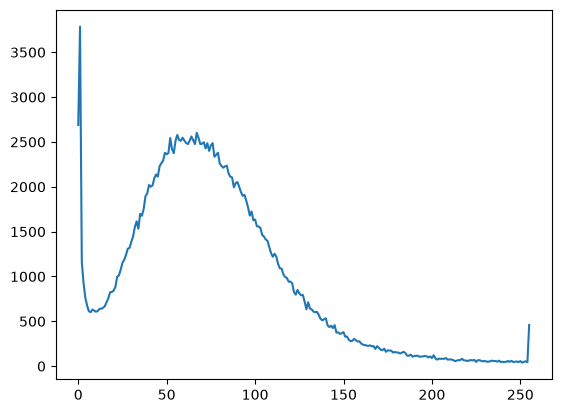

In [3]:
histSize = 256
histRange = (0, 256)
hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=False)
plt.plot(hist)
plt.show()


3. Реализуйте алгоритм гамма коррекции с параметром гамма <1, >1

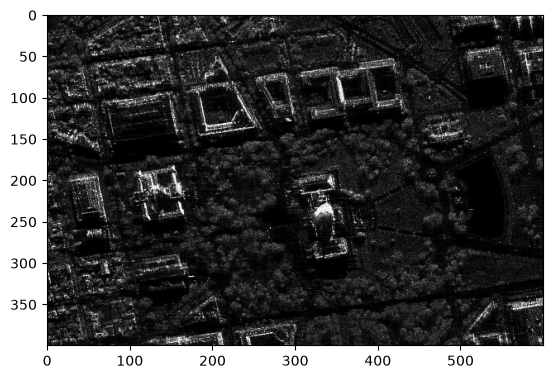

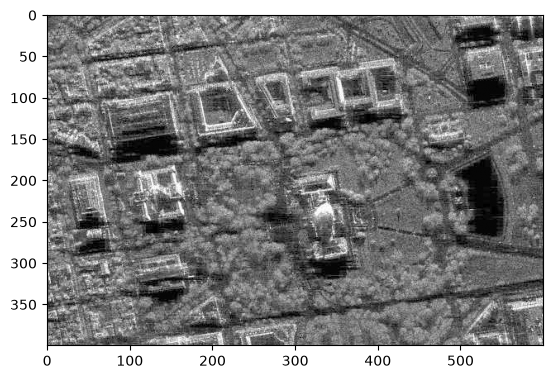

In [4]:
gamma_less = np.array(255 * (image_gray / 255.0) ** (1.0 / 0.5), dtype='uint8')
gamma_more = np.array(255 * (image_gray / 255.0) ** (1.0 / 1.5), dtype='uint8')

plt.imshow(gamma_less, cmap='gray')
plt.show()

plt.imshow(gamma_more, cmap='gray')
plt.show()

4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM

In [5]:
(ssim_less, diff_less) = structural_similarity(image_gray, gamma_less, full=True)
mse_less = mean_squared_error(image_gray, gamma_less)
print("0.5 SSIM:", ssim_less, "MSE:", mse_less)

(ssim_more, diff_more) = structural_similarity(image_gray, gamma_more, full=True)
mse_more = mean_squared_error(image_gray, gamma_more)
print("1.5 SSIM:", ssim_more, "MSE:", mse_more)

0.5 SSIM: 0.5270459922820343 MSE: 2383.7636375
1.5 SSIM: 0.8939717313812034 MSE: 1114.4519291666666


**Гамма 0.5 - SSIM: 0.5270459922820343 MSE: 2383.7636375**

**Гамма 1.5 - SSIM: 0.8939717313812034 MSE: 1114.4519291666666**

5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray

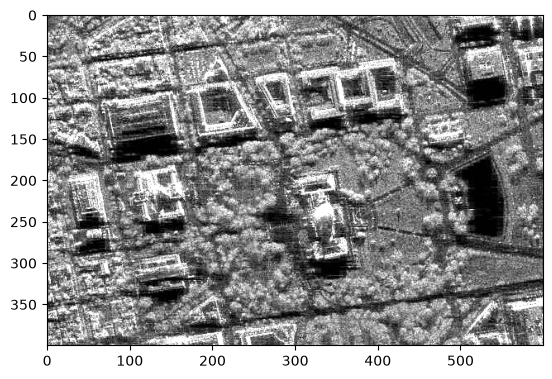

In [6]:
eq_gray = cv2.equalizeHist(image_gray)

mean_orig = image_gray.mean()
std_orig = image_gray.std()
mean_eq = eq_gray.mean()
std_eq = eq_gray.std()

image_stat = (image_gray - mean_orig) * (std_eq / std_orig) + mean_eq
image_stat = np.clip(image_stat, 0, 255).astype('uint8')

plt.imshow(image_stat, cmap='gray')
plt.show()

6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами

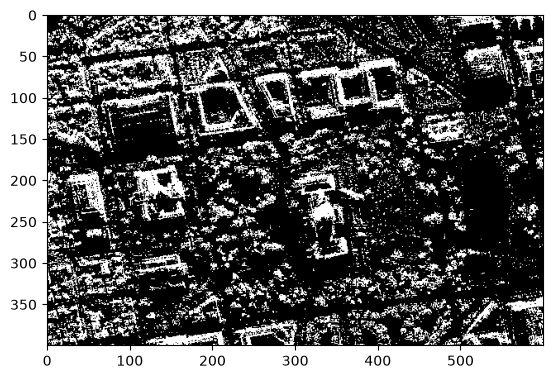

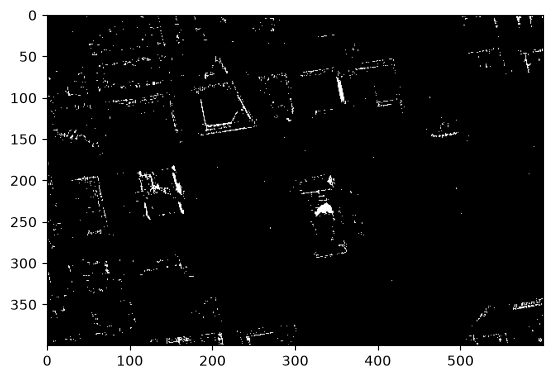

In [7]:
_, thresh_100 = cv2.threshold(image_gray, 100, 255, cv2.THRESH_BINARY)
_, thresh_200 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY)

plt.imshow(thresh_100, cmap='gray')
plt.show()

plt.imshow(thresh_200, cmap='gray')
plt.show()